# 05 — ML SED Completion

This notebook demonstrates how to use the ML completer to extend incomplete SEDs to broader wavelength ranges.

**Use case:** You have a stellar library with limited wavelength coverage (e.g. optical-only) and need UV or IR extensions for MESA.

**Key class:** `MLCompleter` (accessed via `SED.ml_completer()`)

**Approach:** A neural network learns corrections to a blackbody baseline, trained on a complete-coverage library. Masked training handles heterogeneous input wavelength grids.

In [8]:
from sed_tools.api import SED
import matplotlib.pyplot as plt
import numpy as np

## 1. Initialising the Completer

`SED.ml_completer()` returns an `MLCompleter` instance. By default it looks for saved models under `models/`.

In [11]:
completer = SED.ml_completer()
print("MLCompleter initialised")
print("  completer.train(grid=...)   — train on a catalog")
print("  completer.load(name=...)    — load a saved model")
print("  completer.extend(catalog=...) — extend an incomplete catalog")

MLCompleter initialised
  completer.train(grid=...)   — train on a catalog
  completer.load(name=...)    — load a saved model
  completer.extend(catalog=...) — extend an incomplete catalog


## 2. Training

Train on any catalog that has broad wavelength coverage. The model learns the mapping from an incomplete wavelength region + stellar parameters to the missing flux.

In [12]:
# Train on the Kurucz catalog (full UV–IR coverage)
completer.train(
    grid='Kurucz2003all',
    epochs=200,
    batch_size=32,
    save_name='completer_kurucz',
)

Loading flux cube...
  Grid: 17 Teff × 5 logg × 5 [M/H] = 425 total SEDs
  Sampling 425 SEDs for training
  Prepared 425 valid samples
  Known region width: 400 points (randomized position)
  Average extension coverage: 52.2%
Normalizing data...
  X (known) log10 range: [-20.00, 7.88]
  y (ext) log10 range: [-20.00, 7.85]
  Input shape: (425, 403)
  Output shape: (425, 1000)
  Masks shape: (425, 1000)
Building network: 400 + 3 -> [256, 128, 64] -> 1000

Training for up to 200 epochs...
------------------------------------------------------------
  Epoch  10: train_loss=0.711724, val_loss=0.690351, lr=1.00e-04
  Epoch  20: train_loss=0.405266, val_loss=0.389423, lr=1.00e-04
  Epoch  30: train_loss=0.219560, val_loss=0.208688, lr=1.00e-04
  Epoch  40: train_loss=0.125315, val_loss=0.104175, lr=1.00e-04
  Epoch  50: train_loss=0.072160, val_loss=0.059915, lr=1.00e-04
  Epoch  60: train_loss=0.048103, val_loss=0.032822, lr=1.00e-04
  Epoch  70: train_loss=0.042732, val_loss=0.025068, lr=1.

## 3. Loading a Pre-trained Model

In [13]:
completer.load('completer_kurucz')

Loaded model from: /home/njm/SED_Tools/data/stellar_models/models/completer_kurucz


## 4. Extending an Incomplete Catalog

`completer.extend()` applies the trained model to every spectrum in a catalog and returns a `Catalog` object. Write it to disk first, then load it with `SED.local()` to get an interpolatable `SED` instance.

In [14]:
# Extend the hres model (optical only, 3000–7000 Å) to full UV–IR
extended_cat = completer.extend(
    'hres',
    wavelength_range=(100, 100000),  # target range in Å
)


extended_cat.write()

# Then load as an SED instance for interpolation
extended = SED.local('hres_extended')

Extended SED: 3000-6997 Å → 100-100000 Å
Extended SED: 3000-6997 Å → 100-100000 Å
Extended SED: 3000-6997 Å → 100-100000 Å
Extended SED: 3000-6997 Å → 100-100000 Å
Extended SED: 3000-6997 Å → 100-100000 Å
Extended SED: 3000-6997 Å → 100-100000 Å
Extended SED: 3000-6997 Å → 100-100000 Å
Extended SED: 3000-6997 Å → 100-100000 Å
Extended SED: 3000-6997 Å → 100-100000 Å
Extended SED: 3000-6997 Å → 100-100000 Å
Extended SED: 3000-6997 Å → 100-100000 Å
Extended SED: 3000-6997 Å → 100-100000 Å
Extended SED: 3000-6997 Å → 100-100000 Å
Extended SED: 3000-6997 Å → 100-100000 Å
Extended SED: 3000-6997 Å → 100-100000 Å
Extended SED: 3000-6997 Å → 100-100000 Å
Extended SED: 3000-6997 Å → 100-100000 Å
Extended SED: 3000-6997 Å → 100-100000 Å
Extended SED: 3000-6997 Å → 100-100000 Å
Extended SED: 3000-6997 Å → 100-100000 Å
Extended SED: 3000-6997 Å → 100-100000 Å
Extended SED: 3000-6997 Å → 100-100000 Å
Extended SED: 3000-6997 Å → 100-100000 Å
Extended SED: 3000-6997 Å → 100-100000 Å
Extended SED: 30

## 5. Visualising the Extension

Compare the original truncated spectrum against the ML-extended version.

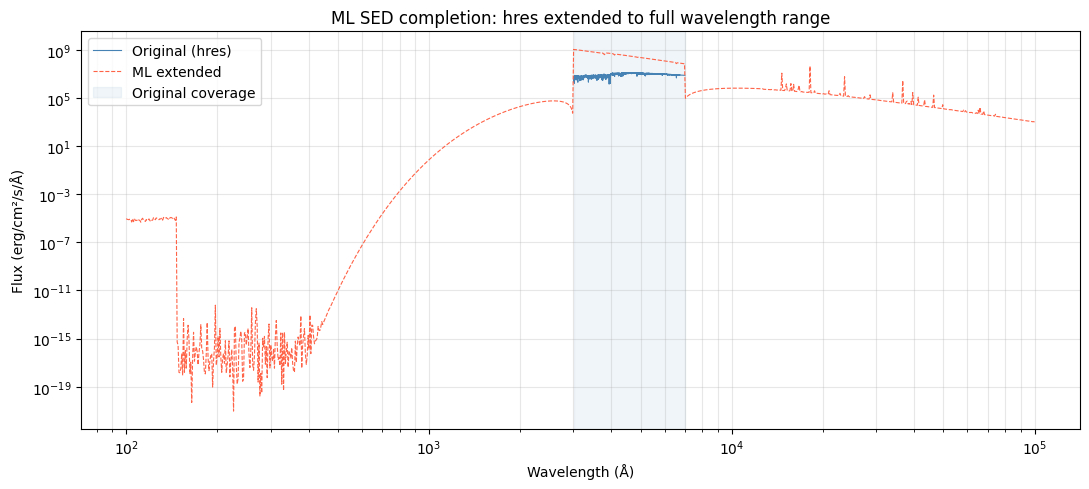

In [15]:
if 'extended' in locals():
    original = SED.local('hres')
    spec_orig = original(teff=6000, logg=4.5, metallicity=0.0)
    spec_ext  = extended(teff=6000, logg=4.5, metallicity=0.0)

    fig, ax = plt.subplots(figsize=(11, 5))
    ax.plot(spec_orig.wl, spec_orig.fl, lw=0.8, label='Original (hres)', color='steelblue')
    ax.plot(spec_ext.wl,  spec_ext.fl,  lw=0.8, label='ML extended',     color='tomato',
            linestyle='--')
    ax.axvspan(spec_orig.wl.min(), spec_orig.wl.max(), alpha=0.08, color='steelblue',
               label='Original coverage')
    ax.set_xscale('log')
    ax.set_yscale('log')
    ax.set_xlabel('Wavelength (Å)')
    ax.set_ylabel('Flux (erg/cm²/s/Å)')
    ax.set_title('ML SED completion: hres extended to full wavelength range')
    ax.legend()
    ax.grid(True, alpha=0.3, which='both')
    plt.tight_layout()
    plt.show()